In [74]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.99'

import e3x
import flax.linen as nn
import functools
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np
import optax

from euclidean_fast_attention import rope
from euclidean_fast_attention.utils.nacl_toy import NaClPotential
from euclidean_fast_attention.utils import nacl_toy
import time

jax.config.update("jax_enable_x64", True)

In [5]:
def rope_energy_fn(pos, q, coeff, graph_mask, batch_segments, lebedev_num=1000, max_theta=2*np.pi):
    """
    Compute the total energy of a system using ERoPE (Euclidean Rotary Position Embedding)
    in the frequency domain.

    Args:
        pos: jnp.ndarray of shape (N, 3)
            The positions of the N particles in 3D space.
        q: jnp.ndarray of shape (N,)
            The charges of the N particles.
        coeff: jnp.ndarray of shape (2K,)
            The coefficients for the frequency domain representation.
        graph_mask: jnp.ndarray of shape (num_graphs,)
            Boolean mask indicating which graphs in a batch are valid (not padding).
        batch_segments: jnp.ndarray of shape (N,)
            Integer array mapping each particle to its graph index in a batch.
        lebedev_num: int, optional (default=1000)
            Number of Lebedev grid points to use for spherical integration.

    Returns:
        energy: float or jnp.ndarray
            The total energy computed using ERoPE, summed over all valid graphs in the batch.
    """
    ke = 14.399645351950548

    with jax.ensure_compile_time_eval():
        grid_u, grid_w = e3x.so3.lebedev_quadrature(
                    num=lebedev_num
                ) # (M, 3), (M, )
    
        theta = jnp.linspace(0, max_theta, len(coeff) // 2, endpoint=False)  # (K)

    coeff_q = jnp.expand_dims(q, axis=1) * jnp.expand_dims(coeff, axis=0)  # (N, 2K)
    coeff_q = coeff_q[:, None, None, :]  # (N, 1, 1, 2K)
    v = jnp.ones((len(coeff_q), 1, 1, 1))  # (N, 1, 1, 1)

    per_atom_energy = rope.apply(
        q=coeff_q*jnp.sqrt(coeff_q.shape[-1]),
        k=coeff_q,
        v=v,
        pos=pos,
        theta=theta,
        grid_u=grid_u,
        grid_w=grid_w,
        graph_mask=graph_mask,
        batch_segments=batch_segments
    )  # (N, 1, 1, 1)

    self_energy = jnp.square(coeff_q).sum(axis=-1, keepdims=True)
    self_energy = jax.ops.segment_sum(self_energy, segment_ids=batch_segments, num_segments=len(graph_mask))
    self_energy = jnp.squeeze(self_energy, axis=(1, 2, 3))

    full_energy = jax.ops.segment_sum(per_atom_energy, segment_ids=batch_segments, num_segments=len(graph_mask))
    full_energy = jnp.squeeze(full_energy, axis=(1, 2, 3))

    return ke * (full_energy - self_energy) / 2.0

In [70]:
# ERope.
num_features = 128
lebedev_num = 2000
max_theta = np.pi

# Training.
initial_learning_rate = 1e-3
max_num_steps = 1_000
rotate = True
seed = 42

# Data.
xmin = 0.0
xmax = 55.0
num_samples = 512

In [71]:
# Initialize params / coefficients.
coeff = jnp.linspace(
    jnp.sqrt(1 / num_features), 0.0, num_features, endpoint=False
)

params = {'coeff': coeff}

# Set up the optimizer.
learning_rate = optax.cosine_decay_schedule(
    initial_learning_rate, max_num_steps
)

optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)

In [72]:
# 10% buffer so there are not artefacts at the edge.
xmax_sample = xmax * 1.10 
xmin_sample = xmin * 0.90

x_base = jnp.linspace(xmin_sample, xmax_sample, num_samples)
x_delta = 0.5 * xmax_sample / (num_samples - 1)

# Draw random positions for the first atom.
vec_key, rot_key = jax.random.split(jax.random.PRNGKey(0))
v1 = jax.random.normal(vec_key, (x_base.size, 3))

# Obtain displacements to the second atom.
u = jnp.zeros((num_samples, 3)).at[:, 0].set(x_base)

if rotate:
    rot = e3x.so3.random_rotation(rot_key, num=x_base.size)
else:
    rot = jnp.eye(3)[None]

# Obtain the position of the second node / atom.
v2 = v1 + jnp.einsum('...ij, ...j -> ...i', rot, u)

# Create an array for the positions.
pos = jnp.stack(
    [
        v1, v2
    ],
    axis=1
)

# Charges
q = jnp.array([1.0, -1.0])

# Batch it.
pos_batched = pos.reshape(-1, 3)
q_batched = jnp.tile(q, len(x_base))
z_batched = jnp.where(q > 0, 11, 17)
batch_segments = jnp.stack([jnp.arange(len(x_base)), jnp.arange(len(x_base))], axis=1).reshape(-1)
graph_mask_batched = jnp.array([True]*len(x_base))

# Assume sparse index format.
src_idx = jnp.tile(jnp.array([1, 0]), len(x_base)) + (jnp.array([1, 1])[None] * jnp.arange(2*len(x_base), step=2)[:, None]).reshape(-1)
dst_idx = jnp.tile(jnp.array([0, 1]), len(x_base)) + (jnp.array([1, 1])[None] * jnp.arange(2*len(x_base), step=2)[:, None]).reshape(-1)

# Create the ground true NaCl potential for on-the-fly data-generation.
nacl_potential = NaClPotential.create(pbc_bool=False, repulsion_bool=False)


def rope_energy_and_forces_fn(pos, q, coeff, graph_mask, batch_segments):
    def energy_fn(p):
        rope_energy = rope_energy_fn(
            pos=p,
            q=q,
            coeff=coeff,
            graph_mask=graph_mask,
            batch_segments=batch_segments,
            lebedev_num=lebedev_num,
            max_theta=max_theta
        )
        energy_per_graph = jnp.where(graph_mask, rope_energy, 0.0)
        return -jnp.sum(energy_per_graph), energy_per_graph
    
    energy_and_forces_fn = jax.value_and_grad(
                energy_fn, argnums=0, has_aux=True
            )
    (_, energy), forces = energy_and_forces_fn(
        pos
    )

    return energy, forces


def NaCl_energy_and_force_fn(positions, atomic_numbers, charges, src_idx, dst_idx, batch_segments, graph_mask):
    def energy_fn(pos):
        return nacl_potential.real_space(
            pos,
            atomic_numbers=atomic_numbers,
            charges=charges,
            src_idx=src_idx,
            dst_idx=dst_idx,
            batch_segments=batch_segments,
            graph_mask=graph_mask
        )
    (_, energy), forces = jax.value_and_grad(energy_fn, has_aux=True)(
            positions
        )

    return energy, forces


# Train step.
def train_step(key, opt_state, params, optimizer_update):
    def loss_fn(params, pos, energy_true, forces_true):
        energy_pred, forces_pred = rope_energy_and_forces_fn(
            pos=pos, 
            q=q_batched, 
            coeff=params['coeff'], 
            graph_mask=graph_mask_batched, 
            batch_segments=batch_segments
        )
        loss = 0.5 * jnp.mean(optax.l2_loss(energy_pred, energy_true)) + 0.5 * jnp.mean(optax.l2_loss(forces_pred, forces_true))
        return loss, (energy_pred, forces_pred)

    x_key, rot_key = jax.random.split(key, num=2)

    # Generate data.
    x = jnp.clip(
        x_base
        + jax.random.uniform(
            x_key, x_base.shape, x_base.dtype, -x_delta, x_delta
        ),
        xmin_sample,
        xmax_sample,
    )

    # Obtain displacements to the second atom.
    u = jnp.zeros((num_samples, 3)).at[:, 0].set(x)

    if rotate:
        rot = e3x.so3.random_rotation(rot_key, num=x.size)
    else:
        rot = jnp.eye(3)[None]

    # Obtain the position of the second node / atom.
    v2 = v1 + jnp.einsum('...ij, ...j -> ...i', rot, u)

    # Create an array for the positions.
    pos = jnp.stack(
        [
            v1, v2
        ],
        axis=1
    ).reshape(-1, 3)

    energy_true, forces_true = NaCl_energy_and_force_fn(
        pos,
        charges=q_batched,
        atomic_numbers=z_batched,
        src_idx=src_idx,
        dst_idx=dst_idx,
        batch_segments=batch_segments,
        graph_mask=graph_mask_batched

    )

    (loss, ys), grad = jax.value_and_grad(loss_fn, has_aux=True)(params, pos, energy_true, forces_true)

    updates, opt_state = optimizer_update(grad, opt_state, params)
    params = optax.apply_updates(params, updates)
    return loss, ys, opt_state, params


jitted_train_step = jax.jit(
    functools.partial(train_step, optimizer_update=optimizer.update)
)

In [73]:
key = jax.random.PRNGKey(seed)

best_loss = jnp.inf
best_params = params
for step in range(max_num_steps):
  key, sample_key = jax.random.split(key)
  loss, ys, opt_state, params = jitted_train_step(sample_key, opt_state, params)
  if loss.item() < best_loss:
    best_loss = loss.item()
    best_params = params
  if step % 10 == 0:
    print(step, loss.item())
params = best_params
print('best loss', best_loss)

0 0.18429678411844858
10 0.08447719407459651
20 0.032229142070850016
30 0.016485888747165535
40 0.009013368082165267
50 0.004309028834449599
60 0.0020915640261536784
70 0.001001624061520606
80 0.00047578199325745886
90 0.0002489804689085345
100 0.00015022385535765775
110 0.00011124580630988836
120 8.490534944164493e-05
130 7.065770769009306e-05
140 6.875879910453639e-05
150 6.35252630534035e-05
160 5.054916732684031e-05
170 4.568482280936654e-05
180 3.8454913607509864e-05
190 3.867312468372817e-05
200 4.077214102675058e-05
210 2.964565346491976e-05
220 3.190253979584795e-05
230 2.77339151793142e-05
240 2.3240563173225672e-05
250 2.849062196640752e-05
260 2.442407606586653e-05
270 2.1855456504035874e-05
280 2.031436593042642e-05
290 1.8839827140669468e-05
300 1.835366049900989e-05
310 1.9915392997262213e-05
320 1.695774532714972e-05
330 1.654886815891009e-05
340 1.3502241122441628e-05
350 1.3428922264941204e-05
360 1.4426838215441008e-05
370 1.507554629605927e-05
380 1.1177996833733693e

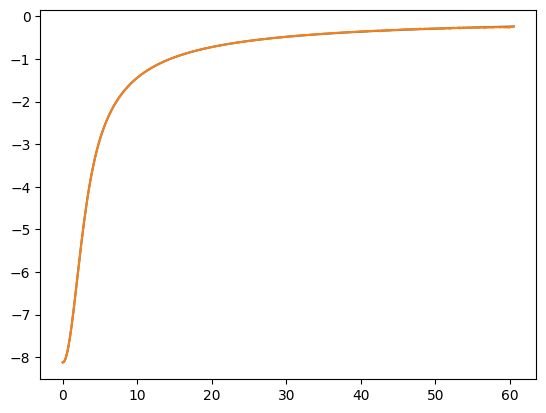

In [75]:
energy_true, forces_true = NaCl_energy_and_force_fn(
        pos_batched,
        charges=q_batched,
        atomic_numbers=z_batched,
        src_idx=src_idx,
        dst_idx=dst_idx,
        batch_segments=batch_segments,
        graph_mask=graph_mask_batched

    )

energy_rope = rope_energy_fn(
    pos=pos_batched,
    q=q_batched,
    coeff=params['coeff'],
    graph_mask=graph_mask_batched,
    batch_segments=batch_segments,
    lebedev_num=lebedev_num,
    max_theta=max_theta
)

plt.plot(x_base, energy_true)
plt.plot(x_base, energy_rope)

In [80]:
def NaCl_energy_fn(positions, atomic_numbers, charges, src_idx, dst_idx, batch_segments, graph_mask):
    return nacl_potential.real_space(
            positions,
            atomic_numbers=atomic_numbers,
            charges=charges,
            src_idx=src_idx,
            dst_idx=dst_idx,
            batch_segments=batch_segments,
            graph_mask=graph_mask
        )[1]
    

# Do a quick check up to 4k atoms.
num_atoms = [64, 128, 256, 512, 1_024, 2_048, 4_096]

# Uncomment to go all the way up to 16k atoms.
# Takes longer since creating the test geometries becomes a bottleneck.

# num_atoms = [64, 128, 256, 512, 1_024, 2_048, 4_096, 8_192, 16_384]

Ds = [50]*len(num_atoms)

print(f'Analyse {len(num_atoms)} systems with num. atoms: {num_atoms}')

rows = list()
rows_model = list()
for i, N in enumerate(num_atoms):
    print(f'Running for N: {N} with D: {Ds[i]}')
    
    np.random.seed(0)
    jax.clear_caches()
    
    dst_idx, src_idx = None, None
    batch_segments = np.zeros((N, ), dtype=int)
    graph_mask = np.array([True])

    jit_NaCl_energy_fn = jax.jit(NaCl_energy_fn)
    jit_rope_energy_fn = jax.jit(rope_energy_fn)

    energy_mae = 0.0
    energies_gt = list()
    energies_ml = list()
    time_potential = 0.0
    time_efa = 0.0

    num_test = min(100 * int(np.floor(max(num_atoms)) / N), 250)
    print(f'Collect metrics from num. test: {num_test} data points.')
    for n in range(num_test):
        print(f'\rGenerate Geometries {n}/{num_test}.', end='', flush=True)
        numbers, positions = nacl_toy.place_atoms_in_sphere(diameter=Ds[i], n_total=N)
        charges = np.where(numbers == 17, -1, 1)

        
        print(f'\rCalculate ref. data {n}/{num_test}.', end='', flush=True)
        start = time.time()
        energy_gt = jax.block_until_ready(
            jit_NaCl_energy_fn(
                positions=positions, 
                atomic_numbers=numbers, 
                charges=charges, 
                src_idx=src_idx, 
                dst_idx=dst_idx,
                batch_segments=batch_segments,
                graph_mask=graph_mask
            )
        )
        end = time.time()
        time_potential += (end - start)
        print(f'\rCalculate EFA {n}/{num_test}.', end='', flush=True)
        start = time.time()
        energy_ml = jax.block_until_ready(
            jit_rope_energy_fn(
                pos=positions,
                q=charges,
                coeff=params['coeff'],
                graph_mask=graph_mask,
                batch_segments=batch_segments,
                max_theta=max_theta
            )
        )
        end = time.time()
        time_efa += (end - start)

        energies_gt.append(np.array(energy_gt).item())
        energies_ml.append(np.array(energy_ml).item())
        energy_mae += np.mean(np.abs(energy_ml - energy_gt))

    energy_mae /= num_test
    time_potential /= num_test
    time_efa /= num_test

    rows.append(
        {
            'energy_mae': energy_mae, 
            'energy_mae_per_atom': energy_mae / N, 
            'num_atoms': N,
            'time_efa': time_efa,
            'time_potential': time_potential,
            'energies_gt': energies_gt,
            'energies_ml': energies_ml,
        }
    )

Analyse 7 systems with num. atoms: [64, 128, 256, 512, 1024, 2048, 4096]
Running for N: 64 with D: 50
Collect metrics from num. test: 250 data points.
Generate Geometries 0/250.

Calculate ref. data 0/250.

/usr/local/lib/python3.12/site-packages/numpy/_core/numeric.py:366: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


Calculate EFA 249/250.9/250.Running for N: 128 with D: 50
Collect metrics from num. test: 250 data points.
Calculate EFA 249/250.9/250.Running for N: 256 with D: 50
Collect metrics from num. test: 250 data points.
Calculate EFA 249/250.9/250.Running for N: 512 with D: 50
Collect metrics from num. test: 250 data points.
Calculate EFA 249/250.9/250.Running for N: 1024 with D: 50
Collect metrics from num. test: 250 data points.
Calculate EFA 249/250.9/250.Running for N: 2048 with D: 50
Collect metrics from num. test: 200 data points.
Calculate EFA 199/200.9/200.Running for N: 4096 with D: 50
Collect metrics from num. test: 100 data points.
Calculate EFA 99/100.9/100.

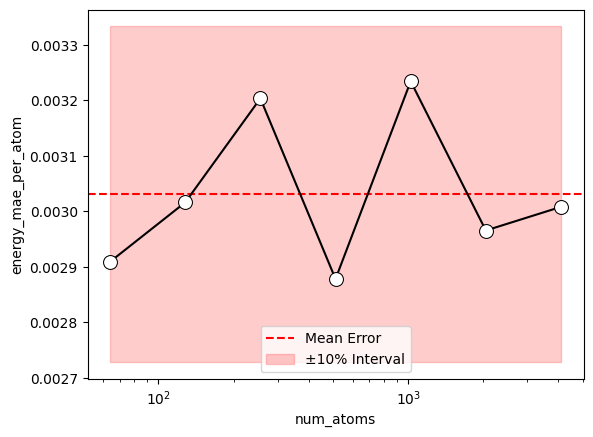

In [81]:
import pandas as pd
import seaborn as sns

# Note that there can be slight deviations from the plot in the paper, since results can differ between GPUs. However, differences are only in the order of ~ 0.1 meV).

df = pd.DataFrame(rows)
df['num_atoms'] = df.num_atoms.astype(int)
error_mean = df.energy_mae_per_atom.mean()
plt.axhline(error_mean, color='red', linestyle='--', label='Mean Error')
plt.fill_between(df['num_atoms'].sort_values(), error_mean * 0.9, error_mean * 1.1, color='red', alpha=0.2, label='±10% Interval')
sns.lineplot(data=df, x='num_atoms', y='energy_mae_per_atom', marker='o', c='k', markerfacecolor='white', markeredgecolor='black', markersize=10)
plt.legend()
plt.xscale('log')